In [ ]:
# !pip install pandas
# !pip install matplotlib
# !pip install openpyxl
# !pip install scikit-learn
# !pip install seaborn
# !pip install statsmodels
# !pip install xgboost

In [1]:
# Initialization of packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
import sklearn
import seaborn as sns
import statsmodels.api as sm
import glob
import os
import re


from xgboost import XGBClassifier

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import RandomForestClassifier

from ModelingFunctions.GEMpythonlib.GEMpythonfunctions import *
from statsmodels.tsa.stattools import acf



In [112]:
#additional functions
def autocorrelation_check(df, column, window_size, acf_lags, acf_threshold):
    # Column name to store the flag
    flag_col_name = f'ac_ws{window_size}_lags{acf_lags}_thres{acf_threshold}'

    osc_flags = []

    # Sliding window
    for i in range(len(df[column]) - window_size + 1):
        window = df[column].iloc[i:i+window_size]
        acf_vals = acf(window, nlags=acf_lags, fft=False)

        # Ignore lag 0 (always 1), take the max of the rest
        max_acf = np.max(np.abs(acf_vals[1:]))
        is_oscillating = max_acf > acf_threshold
        osc_flags.append(is_oscillating)

    # Padding the beginning to align the list with the DataFrame index
    padded_flags = [False] * (window_size - 1) + osc_flags

    # Assign the result to a new column in the DataFrame
    df[flag_col_name] = padded_flags

    return df

In [4]:
# Define the columns and the prefixes you want to use
columns_to_compare = [
    ('Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 'freq_lab'),
    ('Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 'freq_clinique'),
    ('Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 'volt_lab'),
    ('Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 'volt_clinique')
]

# Array or dataframe initialization
data = []

# Constant initialization
minutes_interval = 2

# Constants
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

# unit changes
kwh_to_hp_hr = 1.341
lb_to_gr = 453.592


# List of emissions
emissions = ['NOx', 'CO', 'SOx', 'CO2', 'PM']

# 1. Loading the Data

In [5]:
# Opening files
file_list = ['Voltage Time Series-data-2024-09-15 15_04_52.csv',  
             'Voltage Time Series-data-2024-09-15 15_05_24.csv', 
             'Voltage Time Series-data-2024-09-15 15_06_06.csv',
             'Voltage Time Series-data-2024-09-15 15_06_22.csv',
             'Voltage Time Series-data-2024-09-15 15_05_49.csv',
             'Voltage Time Series-data-2024-10-28 21_01_48.csv',
             'Voltage Time Series-data-2024-10-28 21_02_00.csv',
             'Voltage Time Series-data-2024-10-28 21_02_17.csv',
             'Voltage Time Series-data-2024-10-28 21_02_43.csv']

file_path = '../data/training/'

# Initialize an empty list to collect DataFrames
data_frames = []

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path + file)
    data_frames.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

FileNotFoundError: [Errno 2] No such file or directory: 'data/training/Voltage Time Series-data-2024-09-15 15_04_52.csv'

In [ ]:
# Sort values by 'Time' in ascending order
data.sort_values('Time', ascending=True, inplace=True)

# Now you can proceed to drop the duplicates as before
data.drop_duplicates(subset='Time', inplace=True)

# Reset the index after dropping duplicates
data.reset_index(drop=True, inplace=True)

# Display the cleaned data
display(data)

In [ ]:
# Checking if all rows have the same date time format:

data['Time'] = pd.to_datetime(data['Time'], format="%m/%d/%y %H:%M")
data['Time'].dtype

In [ ]:
# Check interval of data:

is_valid, invalid_data = check_time_intervals(data)

# If there are invalid rows, display them
if not is_valid:
    print("Invalid rows:")
    display(invalid_data)
    
#display(data.iloc[10078:10082])

In [ ]:
# Convert 'Time' column to datetime format
data['Time'] = pd.to_datetime(data['Time'])

# Plot Frequency for both facilities
plt.figure(figsize=(14, 6))

# Plot Frequency for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data['Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'], label='Laboratoire Frequency', color='blue')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Frequency for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data['Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'], label='Clinique Frequency', color='green')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

# Plot Voltage for both facilities
plt.figure(figsize=(14, 6))

# Plot Voltage for Laboratoire
plt.subplot(1, 2, 1)
plt.plot(data['Time'], data['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'], label='Laboratoire Voltage', color='red')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Laboratoire')
plt.xticks(rotation=45)
plt.legend()

# Plot Voltage for Clinique
plt.subplot(1, 2, 2)
plt.plot(data['Time'], data['Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'], label='Clinique Voltage', color='orange')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.title('Voltage - Clinique')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# List of columns to calculate statistics
columns_of_interest = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'
]

# Calculate the statistics for each column, including mean, median, percentiles, and null counts
stats = data[columns_of_interest].agg([
    'mean',
    'median',
    lambda x: x.quantile(0.01),  # 1st percentile
    lambda x: x.quantile(0.99),  # 99th percentile
    lambda x: x.isnull().sum()/x.sum()*100  # Null counts
])

# Renaming the lambda output columns
stats.columns = columns_of_interest
stats.index = ['Mean', 'Median', '1st Percentile', '99th Percentile', 'Null Count (%)']

# Display the statistics
print(stats)

# 2. Training and Test Data Separation

In [ ]:
# Determine the split index (60% for training)
split_index = int(len(data) * 0.6)

# Split the data into training and testing sets
train_data = data.iloc[:split_index]
test_data = data.iloc[split_index:]

# Display the sizes of the train and test sets
print(f'Training data size: {len(train_data)}')
print(f'Test data size: {len(test_data)}')

# Optionally, display the first few rows of each
print("Training Data Sample:")
display(train_data)

print("Test Data Sample:")
display(test_data)

# 3. Voltage and Frequency Only 

#### *3.1. Baseline Model on the Voltage and Frequency only*

-> Choosing only the most from the train set

In [ ]:
train_data_base = train_data.copy()
test_data_base = test_data.copy()

In [ ]:
train_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5
test_data_base['prediction'] = (train_data_base['Generator_ON'].mean()) > 0.5

display('Train data for baseline:')
display(train_data_base['prediction'])

display('Test data for baseline:')
display(test_data_base['prediction'])

Assessing the model:

In [ ]:
# TRAIN DATA EVALUATION
metrics = evaluate_model_performance(train_data_base)

In [ ]:
# TEST DATA EVALUATION
metrics = evaluate_model_performance(test_data_base)

In [ ]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)", include_voltage=False, include_frequency=False)

In [ ]:
# For Baseline Model without voltage
plot_predictions_vs_actuals(train_data_base, model_name="Baseline Model (Train Set)", include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_base, model_name="Baseline Model (Test Set)", include_voltage=True, include_frequency=True)

#### *3.2. Logistic Regression on the Voltage and Frequency only*

In [ ]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

Evaluating the train set - Baseline Logistic Regression:

In [6]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:


NameError: name 'y_train' is not defined

Evaluating the test set - Baseline Logistic Regression:

In [7]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:


NameError: name 'y_test' is not defined

#### *3.3. Random Forrest on the Voltage and Frequency only*

In [8]:
# Step 1: Create copies of the original data
train_data_rf = train_data.copy()
test_data_rf = test_data.copy()

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_rf[feature_columns]
y_train = train_data_rf['Generator_ON']

X_test = test_data_rf[feature_columns]
y_test = test_data_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_rf['prediction'] = clf.predict(X_train)
test_data_rf['prediction'] = clf.predict(X_test)

NameError: name 'train_data' is not defined

Evaluating the train set (Random Forrest): 

In [9]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_rf['prediction'].value_counts())

Train Set Evaluation:


NameError: name 'y_train' is not defined

Evaluating the test set (Random Forrest): 

In [10]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_rf['prediction'].value_counts())

Test Set Evaluation:


NameError: name 'y_test' is not defined

#### *3.4. XG-Boost on the Voltage and Frequency only*

In [11]:
# Step 0: Copy rf data
train_data_boost = train_data.copy()
test_data_boost = test_data.copy()

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)'
]


# Step 1: Use the same data and feature columns
X_train = train_data_boost[feature_columns]
y_train = train_data_boost['Generator_ON']

X_test = test_data_boost[feature_columns]
y_test = test_data_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
    use_label_encoder=False  # Avoid unnecessary warnings
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_boost['prediction'] = xgb_clf.predict(X_train)
test_data_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

NameError: name 'train_data' is not defined

In [12]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):


NameError: name 'y_train' is not defined

In [13]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):


NameError: name 'y_test' is not defined

# 4. Feature Generation

### 4.1. Using Mean as a Threshold

In [14]:
train_data_mean = train_data.copy()
test_data_mean = test_data.copy()

NameError: name 'train_data' is not defined

In [15]:
# Taking the mean of the dataframe
train_data_mean, test_data_mean = calculate_mean_flags(train_data_mean, test_data_mean, train_data_base, columns_to_compare)

# Display the updated data
display(train_data_mean)
display(test_data_mean)

NameError: name 'train_data_mean' is not defined

#### 4.1.1. Using Mean as a Threshold - Custom Prediction

In [16]:
# Define custom prediction logic
def custom_prediction(row):
    # Example: Set prediction to True if either clinic or lab has higher frequency and voltage
    if (row['higher_freq_lab'] or row['higher_volt_lab']) and (row['higher_freq_clinique'] or row['higher_volt_clinique']):
        return True
    else:
        return False

# Apply custom prediction logic
train_data_mean['prediction'] = train_data_mean.apply(custom_prediction, axis=1)
test_data_mean['prediction'] = test_data_mean.apply(custom_prediction, axis=1)

# Show prediction:
display('Train data for baseline:')
display(train_data_mean['prediction'].value_counts())

display('Test data for baseline:')
display(test_data_mean['prediction'].value_counts())

NameError: name 'train_data_mean' is not defined

Assessing the mean model: 

In [17]:
metrics = evaluate_model_performance(train_data_mean)

NameError: name 'train_data_mean' is not defined

In [18]:
metrics = evaluate_model_performance(test_data_mean)

NameError: name 'test_data_mean' is not defined

In [19]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)", include_voltage=False, include_frequency=False)

NameError: name 'train_data_mean' is not defined

In [20]:
# For Mean Model without frequency
plot_predictions_vs_actuals(train_data_mean, model_name="Mean Model (Train Set)", include_voltage=True, include_frequency=True)
plot_predictions_vs_actuals(test_data_mean, model_name="Mean Model (Test Set)", include_voltage=True, include_frequency=True)

NameError: name 'train_data_mean' is not defined

#### 4.1.2. Using Mean as a Threshold - Logistic Regression

In [21]:
# Step 1: Create copies of the original data
train_data_mean_lg = train_data.copy()
test_data_mean_lg = test_data.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_mean_lg, test_data_mean_lg = calculate_mean_flags(train_data_mean_lg, test_data_mean_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_lg[feature_columns]
y_train = train_data_mean_lg['Generator_ON']

X_test = test_data_mean_lg[feature_columns]
y_test = test_data_mean_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Linear Regression model
reg = LinearRegression()
reg.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_lg['prediction_value'] = reg.predict(X_train)
test_data_mean_lg['prediction_value'] = reg.predict(X_test)

# Optional: Convert predictions to binary form for classification (e.g., threshold at 0.5)
train_data_mean_lg['prediction'] = (train_data_mean_lg['prediction_value'] >= 0.5).astype(int)
test_data_mean_lg['prediction'] = (test_data_mean_lg['prediction_value'] >= 0.5).astype(int)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_mean_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_mean_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

NameError: name 'train_data' is not defined

Evaluating the train set (Logistic Regression): 

In [22]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_lg['prediction'].value_counts())

Train Set Evaluation:


NameError: name 'y_train' is not defined

Evaluating the test set (Logistic Regression): 

In [23]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_lg['prediction'].value_counts())

Test Set Evaluation:


NameError: name 'y_test' is not defined

In [24]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)", include_voltage=False, include_frequency=False)

NameError: name 'train_data_mean_lg' is not defined

In [25]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)", include_voltage=True, include_frequency=True)
train_data_lg_daily_count = plot_true_predictions_histogram(train_data_mean_lg)
display(train_data_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)", include_voltage=True, include_frequency=True)
test_data_lg_daily_count = plot_true_predictions_histogram(test_data_mean_lg)
display(test_data_lg_daily_count)

NameError: name 'train_data_mean_lg' is not defined

#### 4.1.3. Using Mean as a Threshold - Random Forrest

In [ ]:
# Step 1: Create copies of the original data
train_data_mean_rf = train_data.copy()
test_data_mean_rf = test_data.copy()

# Taking the mean of the dataframe
train_data_mean_rf, test_data_mean_rf = calculate_mean_flags(train_data_mean_rf, test_data_mean_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
       'higher_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_mean_rf[feature_columns]
y_train = train_data_mean_rf['Generator_ON']

X_test = test_data_mean_rf[feature_columns]
y_test = test_data_mean_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_rf['prediction'] = clf.predict(X_train)
test_data_mean_rf['prediction'] = clf.predict(X_test)

Evaluating the train set (Random Forrest): 

In [26]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_mean_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_mean_rf['prediction'].value_counts())

Train Set Evaluation:


NameError: name 'y_train' is not defined

Evaluating the test set (Random Forrest): 

In [27]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_mean_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_mean_rf['prediction'].value_counts())

Test Set Evaluation:


NameError: name 'y_test' is not defined

In [28]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)", include_voltage=False, include_frequency=False)

NameError: name 'train_data_mean_rf' is not defined

In [29]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_rf, model_name="Mean - Random Forest (Train Set)", include_voltage=True, include_frequency=True)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_mean_rf, model_name="Mean - Random Forest (Test Set)", include_voltage=True, include_frequency=True)

NameError: name 'train_data_mean_rf' is not defined

In [30]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_rf)
display_generator_statistics(test_data_mean_rf)

##### PREDICTION RESULT #####


NameError: name 'train_data_mean_rf' is not defined

#### 4.1.4. Using Mean as a Threshold - XGBoost

In [31]:
# Step 0: Copy rf data
train_data_mean_boost = train_data.copy()
test_data_mean_boost = test_data.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_mean_boost, test_data_mean_boost = calculate_mean_flags(train_data_mean_boost, test_data_mean_boost, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_mean_boost[feature_columns]
y_train = train_data_mean_boost['Generator_ON']

X_test = test_data_mean_boost[feature_columns]
y_test = test_data_mean_boost['Generator_ON']


# Step 2: Train an XGBoost Classifier
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='logloss',  # Evaluation metric for binary classification
    use_label_encoder=False  # Avoid unnecessary warnings
)

# Fit the model
xgb_clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_mean_boost['prediction'] = xgb_clf.predict(X_train)
test_data_mean_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

NameError: name 'train_data' is not defined

In [32]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_mean_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):


NameError: name 'y_train' is not defined

In [33]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Test Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_mean_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(train_data_mean_boost['prediction'].value_counts())

Test Set Evaluation (XGBoost):


NameError: name 'y_test' is not defined

In [34]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_mean_boost)
display_generator_statistics(test_data_mean_boost)

##### PREDICTION RESULT #####


NameError: name 'train_data_mean_boost' is not defined

### 4.2. Generating Time Series Feature

In [35]:
## INITIALIZATION OF CONSTANTS
# Range of reasonable frequency and voltage
high_freq_threshold = 60
low_freq_threshold = 40

high_volt_threshold = 250
low_volt_threshold = 2

voltage_delta = 10

In [36]:
train_data_ts = train_data.copy()
test_data_ts = test_data.copy()

NameError: name 'train_data' is not defined

In [37]:
## FEATURE GENERATION
# Using mean to compare
train_data_ts, test_data_ts = calculate_mean_flags(train_data_ts, test_data_ts, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
train_data_ts, test_data_ts = process_time_series_data(train_data_ts, test_data_ts, high_freq_threshold,
                                                       low_freq_threshold, high_volt_threshold, low_volt_threshold)

# Display the processed data
display(train_data_ts)
display(test_data_ts)

NameError: name 'train_data_ts' is not defined

In [38]:
train_data_ts.columns

NameError: name 'train_data_ts' is not defined

#### 4.2.1. Using Mean of Voltage and Frequency as a Threshold and Time Series - Logistic Regression

In [39]:

# Step 1: Create copies of the original data
train_data_ts_lg = train_data_ts.copy()
test_data_ts_lg = test_data_ts.copy()

# Calculate the mean flags (assuming the function 'calculate_mean_flags' is defined)
train_data_ts_lg, test_data_ts_lg = calculate_mean_flags(train_data_ts_lg, test_data_ts_lg, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_lg[feature_columns]
y_train = train_data_ts_lg['Generator_ON']

X_test = test_data_ts_lg[feature_columns]
y_test = test_data_ts_lg['Generator_ON']

# Fill NaN values in training and testing data with the mean of each column
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_train.mean())  # Use training mean to avoid data leakage

# Step 2: Train a Logistic Regression model
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_lg['prediction'] = clf.predict(X_train)
test_data_ts_lg['prediction'] = clf.predict(X_test)

# Print accuracy for classification interpretation
train_accuracy = accuracy_score(y_train, train_data_ts_lg['prediction'])
test_accuracy = accuracy_score(y_test, test_data_ts_lg['prediction'])

print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

# Step 4: Get the feature coefficients (importance in logistic regression)
coefficients = clf.coef_[0]  # Extract coefficients from the trained model

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Coefficient': coefficients
})

# Sort the features by absolute value of the coefficient and keep the top 20
top_20_features = feature_importance_df.reindex(
    feature_importance_df['Coefficient'].abs().sort_values(ascending=False).index
).head(20)

# Display the top 20 most significant features
print("Top 20 features sorted by absolute coefficient value:")
display(top_20_features)

# Visualize the top 20 feature coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Coefficient'])
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.title('Top 20 Feature Coefficients in Logistic Regression Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most significant features on top
plt.show()

NameError: name 'train_data_ts' is not defined

In [40]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_lg['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_lg['prediction'].value_counts())

Train Set Evaluation:


NameError: name 'y_train' is not defined

In [41]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_lg['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_lg['prediction'].value_counts())

Test Set Evaluation:


NameError: name 'y_test' is not defined

In [42]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_lg)
display_generator_statistics(test_data_ts_lg)

##### PREDICTION RESULT #####


NameError: name 'train_data_ts_lg' is not defined

In [43]:
# For Logistic Regression Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_mean_lg, model_name="Mean - Logistic Regression (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_mean_lg, model_name="Mean - Logistic Regression (Test Set)", include_voltage=False, include_frequency=False)

NameError: name 'train_data_mean_lg' is not defined

In [44]:
# For Logistic Regression Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_lg, model_name="Time Series - Logistic Regression (Train Set)", include_voltage=True, include_frequency=True)
train_data_ts_lg_daily_count = plot_true_predictions_histogram(train_data_ts_lg)
display(train_data_ts_lg_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_lg, model_name="Time Series - Logistic Regression (Test Set)", include_voltage=True, include_frequency=True)
test_data_ts_lg_daily_count = plot_true_predictions_histogram(test_data_ts_lg)
display(test_data_ts_lg_daily_count)

NameError: name 'train_data_ts_lg' is not defined

#### 4.2.2. Using Mean of Voltage and Frequency as a Threshold and Time Series - Random Forrest

In [45]:
# Step 1: Create copies of the original data
train_data_ts_rf = train_data_ts.copy()
test_data_ts_rf = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_rf, test_data_ts_rf = calculate_mean_flags(train_data_ts_rf, test_data_ts_rf, train_data_base, columns_to_compare)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

# Use the selected feature columns to predict 'Generator_ON'
X_train = train_data_ts_rf[feature_columns]
y_train = train_data_ts_rf['Generator_ON']

X_test = test_data_ts_rf[feature_columns]
y_test = test_data_ts_rf['Generator_ON']

# Step 2: Train a Random Forest Classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Step 3: Make Predictions on the train and test sets
train_data_ts_rf['prediction'] = clf.predict(X_train)
test_data_ts_rf['prediction'] = clf.predict(X_test)

# Step 4: Get the feature importances
importances = clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 10
top_15_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(50)

# Display the top 15 most important features
print("Top 15 features sorted by importance:")
display(top_15_features)

# Visualize the top 15 feature importances
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(top_15_features['Feature'], top_15_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in Random Forest Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()

NameError: name 'train_data_ts' is not defined

Evaluating the train and test set

In [46]:
# Evaluate on the train set
print("Train Set Evaluation:")
evaluate_model_performance_rf(y_train, train_data_ts_rf['prediction'])

print("Train data prediction distribution:")
print(train_data_ts_rf['prediction'].value_counts())

Train Set Evaluation:


NameError: name 'y_train' is not defined

In [47]:
# Evaluate on the test set
print("Test Set Evaluation:")
evaluate_model_performance_rf(y_test, test_data_ts_rf['prediction'])

print("Test data prediction distribution:")
print(test_data_ts_rf['prediction'].value_counts())

Test Set Evaluation:


NameError: name 'y_test' is not defined

In [48]:
# For Random Forest Model with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)", include_voltage=False, include_frequency=False)
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)", include_voltage=False, include_frequency=False)

NameError: name 'train_data_ts_rf' is not defined

In [49]:
# For Random Forest Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_rf, model_name="Mean - Random Forest (Train Set)", include_voltage=True, include_frequency=True)
train_data_ts_rf_daily_count = plot_true_predictions_histogram(train_data_ts_rf)
display(train_data_ts_rf_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_rf, model_name="Mean - Random Forest (Test Set)", include_voltage=True, include_frequency=True)
test_data_ts_rf_daily_count = plot_true_predictions_histogram(test_data_ts_rf)
display(test_data_ts_rf_daily_count)

NameError: name 'train_data_ts_rf' is not defined

In [50]:
train_data_ts_rf['Generator_ON'].dtype

NameError: name 'train_data_ts_rf' is not defined

In [51]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_rf)
display_generator_statistics(test_data_ts_rf)

##### PREDICTION RESULT #####


NameError: name 'train_data_ts_rf' is not defined

#### 4.2.3. Using Mean of Voltage and Frequency as a Threshold and Time Series - XGBoost

In [52]:

# Step 0: Copy rf data
train_data_ts_boost = train_data_ts.copy()
test_data_ts_boost = test_data_ts.copy()

# Taking the mean of the dataframe (using the previous function)
train_data_ts_boost, test_data_ts_boost = calculate_mean_flags(train_data_ts_boost, test_data_ts_boost, train_data_base, columns_to_compare)


# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]


# Step 1: Use the same data and feature columns
X_train = train_data_ts_boost[feature_columns]
y_train = train_data_ts_boost['Generator_ON']

X_test = test_data_ts_boost[feature_columns]
y_test = test_data_ts_boost['Generator_ON']

X_train['Prev_High_delta_freq_lab'] = pd.to_numeric(X_train['Prev_High_delta_freq_lab'], errors='coerce')
X_train['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_train['Prev_High_delta_freq_clinique'], errors='coerce')
X_train['Prev_High_delta_volt_lab'] = pd.to_numeric(X_train['Prev_High_delta_volt_lab'], errors='coerce')
X_train['Prev_High_delta_volt_clinique'] = pd.to_numeric(X_train['Prev_High_delta_volt_clinique'], errors='coerce')

X_test['Prev_High_delta_freq_lab'] = pd.to_numeric(X_test['Prev_High_delta_freq_lab'], errors='coerce')
X_test['Prev_High_delta_freq_clinique'] = pd.to_numeric(X_test['Prev_High_delta_freq_clinique'], errors='coerce')
X_test['Prev_High_delta_volt_lab'] = pd.to_numeric(X_test['Prev_High_delta_volt_lab'], errors='coerce')
X_test['Prev_High_delta_volt_clinique'] = pd.to_numeric(X_test['Prev_High_delta_volt_clinique'], errors='coerce')


NameError: name 'train_data_ts' is not defined

#### This section is for XGBoost parameter search using cross validation

In [53]:

'''
# Step 2: Train an XGBoost Classifier
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',  # Adjust based on your metric
    cv=3,               # Cross-validation splits
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)


# Step 3: Make Predictions on the train and test sets
train_data_ts_boost['prediction'] = xgb_clf.predict(X_train)
test_data_ts_boost['prediction'] = xgb_clf.predict(X_test)

# Step 4: Evaluate Feature Importances
importances = xgb_clf.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': importances
})

# Sort the features by importance and keep only the top 20
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

# Display the top 20 most important features
print("Top 20 features sorted by importance (XGBoost):")
display(top_20_features)

# Visualize the top 20 feature importances
plt.figure(figsize=(10, 6))
plt.barh(top_20_features['Feature'], top_20_features['Importance'])
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 20 Feature Importance in XGBoost Model')
plt.gca().invert_yaxis()  # Invert y-axis to have the most important on top
plt.show()
'''

'\n# Step 2: Train an XGBoost Classifier\nparam_grid = {\n    \'max_depth\': [3, 5, 7],\n    \'learning_rate\': [0.01, 0.1, 0.2],\n    \'n_estimators\': [100, 300, 500],\n    \'subsample\': [0.6, 0.8, 1.0],\n    \'colsample_bytree\': [0.6, 0.8, 1.0],\n    \'gamma\': [0, 1, 5],\n    \'reg_alpha\': [0, 0.1, 1],\n    \'reg_lambda\': [1, 10, 100]\n}\n\ngrid_search = GridSearchCV(\n    estimator=XGBClassifier(random_state=42),\n    param_grid=param_grid,\n    scoring=\'roc_auc\',  # Adjust based on your metric\n    cv=3,               # Cross-validation splits\n    verbose=2\n)\n\ngrid_search.fit(X_train, y_train)\n\nprint("Best parameters:", grid_search.best_params_)\n\n\n# Step 3: Make Predictions on the train and test sets\ntrain_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_train)\ntest_data_ts_boost[\'prediction\'] = xgb_clf.predict(X_test)\n\n# Step 4: Evaluate Feature Importances\nimportances = xgb_clf.feature_importances_\n\n# Create a DataFrame for better visualization\nfeature

In [54]:
# Use the best parameters from GridSearchCV
best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 300,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'subsample': 1.0
}

# Initialize the model with the best parameters
final_model = XGBClassifier(
    random_state=42,
    **best_params
)

# Fit the model on the entire training data
final_model.fit(X_train, y_train)

# Make predictions on the test set
train_data_ts_boost['prediction'] = final_model.predict(X_train)
test_data_ts_boost['prediction'] = final_model.predict(X_test)

# Evaluate the model on the test set
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, test_data_ts_boost['prediction']))

# AUC-ROC score
print("AUC-ROC Score:")
y_test_proba = final_model.predict_proba(X_test)[:, 1]
print(roc_auc_score(y_test, y_test_proba))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, test_data_ts_boost['prediction']))

NameError: name 'X_train' is not defined

In [55]:
# Step 5: Evaluate Model Performance
# Evaluate on the train set
print("Train Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_train, train_data_ts_boost['prediction'])

print("Train data prediction distribution (XGBoost):")
print(train_data_ts_boost['prediction'].value_counts())

Train Set Evaluation (XGBoost):


NameError: name 'y_train' is not defined

In [56]:
# Evaluate on the test set
print("\nTest Set Evaluation (XGBoost):")
evaluate_model_performance_rf(y_test, test_data_ts_boost['prediction'])

print("Test data prediction distribution (XGBoost):")
print(test_data_ts_boost['prediction'].value_counts())


Test Set Evaluation (XGBoost):


NameError: name 'y_test' is not defined

In [57]:
# For Boosting Model
# Train data with both voltage and frequency
plot_predictions_vs_actuals(train_data_ts_boost, model_name="Mean - XGBoost (Train Set)", include_voltage=True, include_frequency=True)
train_data_ts_boost_daily_count = plot_true_predictions_histogram(train_data_ts_boost)
display(train_data_ts_boost_daily_count)
# Test data with both voltage and frequency
plot_predictions_vs_actuals(test_data_ts_boost, model_name="Mean - XGBoost (Test Set)", include_voltage=True, include_frequency=True)
test_data_ts_boost_daily_count = plot_true_predictions_histogram(test_data_ts_boost)
display(test_data_ts_boost_daily_count)

NameError: name 'train_data_ts_boost' is not defined

In [58]:
print(f'##### PREDICTION RESULT #####')
display_generator_statistics(train_data_ts_boost)
display_generator_statistics(test_data_ts_boost)

##### PREDICTION RESULT #####


NameError: name 'train_data_ts_boost' is not defined

## 5. Applying the Model with Other Data

#### 5.1. Using 1 Month Data and Check the Prediction Result

In [59]:
# Opening files
file_list = ['Voltage Time Series-data-2024-10-25 13_13_06.csv',  
             'Voltage Time Series-data-2024-10-25 13_13_40.csv', 
             'Voltage Time Series-data-2024-10-25 13_14_12.csv',
             'Voltage Time Series-data-2024-10-25 13_14_37.csv',
             'Voltage Time Series-data-2024-10-25 13_18_07.csv']

# Initialize an empty list to collect DataFrames
data_frames_2 = []

file_path_2 = 'data/New 2/'

for file in file_list:
    # Read each file into a DataFrame and append to the list
    monthly_data = pd.read_csv(file_path_2 + file)
    data_frames_2.append(monthly_data)

# Concatenate all DataFrames in the list at once
data = pd.concat(data_frames_2, ignore_index=True)

# Display the final concatenated DataFrame
display(data)

FileNotFoundError: [Errno 2] No such file or directory: 'data/New 2/Voltage Time Series-data-2024-10-25 13_13_06.csv'

In [60]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2, test_data_2_dummy = calculate_mean_flags(data, data, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2, test_data_2_dummy = process_time_series_data(test_data_2, test_data_2, high_freq_threshold,
                                                          low_freq_threshold, high_volt_threshold, low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

NameError: name 'train_data_base' is not defined

In [61]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

NameError: name 'test_data_2' is not defined

In [62]:
test_data_2_daily_count = plot_true_predictions_histogram(test_data_2)
test_data_2_daily_count

NameError: name 'test_data_2' is not defined

#### 5.2. Using 1 Year Data of Year 2023

Loading 1 year data into 1 dataframe:

In [63]:
# Set the path to the folder containing CSV files
folder_path = 'data/2023 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2023 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2023['time'] = pd.to_datetime(data_2023['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2023 = data_2023.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2023

ValueError: No objects to concatenate

In [64]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2023, test_data_2023_dummy = calculate_mean_flags(data_2023, data_2023, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2023, test_data_2023_dummy = process_time_series_data(test_data_2023, test_data_2023, high_freq_threshold,
                                                                low_freq_threshold, high_volt_threshold,
                                                                low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2023)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2023[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2023['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

NameError: name 'data_2023' is not defined

##### 5.2.1. Plot Result During Lost Clinique Data (2023)

In [65]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2023, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

NameError: name 'test_data_2023' is not defined

In [66]:
# Plot predictions based on certain timing choosen

start_date = '2023-12-01 00:00:00'
finished_date = '2023-12-31 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30
average_daily = filtered_test_data_2_daily_count['Minutes'].sum() / filtered_test_data_2_daily_count.shape[0] 
max_daily = filtered_test_data_2_daily_count['Minutes'].max()
# Find the row with the maximum 'Minutes' value
max_daily_row = filtered_test_data_2_daily_count.loc[filtered_test_data_2_daily_count['Minutes'].idxmax()]
# Extract the 'Date' column from that row
max_date = max_daily_row['Date']


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')
print(f'Average Daily Usage Minutes: {average_daily} minutes, or {average_daily / 60} hours')
print(f'Max minutes of usage {max_daily} minutes or {max_daily / 60} hours. Date: {max_date}')

NameError: name 'test_data_2023' is not defined

##### 5.2.2. Plot Result First 10 days of July (2023)

In [67]:
# Plot predictions based on certain timing choosen
start_date = '2023-02-14 00:00:00'
finished_date = '2023-02-17 23:59:59'
filtered_test_data_2023 = test_data_2023[(test_data_2023['Time'] >= start_date) & (test_data_2023['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2023,
    model_name=f"Mean - Random Forest for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)

# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2023)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2023['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2023) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

NameError: name 'test_data_2023' is not defined

#### 5.3. Using Data of Year 2022

Due to data limitations, only Data from 27th May 2022 - 31st December 2022 is available

In [68]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = 'data/2022 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2022 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2022['time'] = pd.to_datetime(data_2022['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2022 = data_2022.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2022


ValueError: No objects to concatenate

In [69]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2022, test_data_2022_dummy = calculate_mean_flags(data_2022, data_2022, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2022, test_data_2022_dummy = process_time_series_data(test_data_2022, test_data_2022, high_freq_threshold,
                                                                low_freq_threshold, high_volt_threshold,
                                                                low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2022)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)', 
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2022[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2022['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2022['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2022) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

NameError: name 'data_2022' is not defined

##### 5.2.2. Plot Result During Lost Clinique Data (2022)

In [70]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2022, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

NameError: name 'test_data_2022' is not defined

In [71]:
# Plot predictions based on certain timing choosen

start_date = '2022-06-20 00:00:00'
finished_date = '2022-06-30 23:59:59'
filtered_test_data_2022 = test_data_2022[(test_data_2022['Time'] >= start_date) & (test_data_2022['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2022,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2022)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2022['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2022) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

NameError: name 'test_data_2022' is not defined

#### 5.4. Using Data of Year 2024

In [72]:
# Loading the data

# Set the path to the folder containing CSV files
folder_path = 'data/2024 Data/'

# Use glob to get all CSV file paths in the folder
csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

# Initialize an empty list to store each DataFrame
dfs = []

# Loop through the file paths and read each CSV into a DataFrame
for file in csv_files:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all DataFrames into one
data_2024 = pd.concat(dfs, ignore_index=True)

# Ensure the 'time' column is in datetime format
data_2024['time'] = pd.to_datetime(data_2024['Time'], format='%Y-%m-%d %H:%M:%S')

# Sort the DataFrame by the 'time' column
data_2024 = data_2024.sort_values(by='time').reset_index(drop=True)

# Display the first few rows to verify
data_2024

ValueError: No objects to concatenate

In [73]:
# Step 1: Generate Features

## FEATURE GENERATION
# Taking the mean of the dataframe (using the previous function)
test_data_2024, test_data_2024_dummy = calculate_mean_flags(data_2024, data_2024, train_data_base, columns_to_compare)

# Assuming train_data_ts and test_data_ts are your DataFrames
test_data_2024, test_data_2024_dummy = process_time_series_data(test_data_2024, test_data_2024, high_freq_threshold,
                                                                low_freq_threshold, high_volt_threshold,
                                                                low_volt_threshold)

# Display Processed data:
print('Processed data after feature generation: ')
display(test_data_2024)

# Define the feature columns
feature_columns = [
    'Frequency 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
    'Frequency C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)',
    'Voltage C30F2E03 (Ch Cbca Bethesda Ndosho - clinique)',
    'higher_freq_lab', 'higher_freq_clinique', 'higher_volt_lab',
    'higher_volt_clinique', 'Freq_delta_lab', 'Freq_delta_clinique',
    'Volt_delta_lab', 'Volt_delta_clinique', 'freq_delta_negative_lab',
    'freq_delta_negative_clinique', 'volt_delta_positive_lab',
    'volt_delta_positive_clinique', 'freq_in_range_lab',
    'volt_in_range_lab', 'freq_in_range_clinique', 'volt_in_range_clinique',
    'Hour_0', 'Hour_1', 'Hour_2', 'Hour_3', 'Hour_4', 'Hour_5', 'Hour_6',
    'Hour_7', 'Hour_8', 'Hour_9', 'Hour_10', 'Hour_11', 'Hour_12',
    'Hour_13', 'Hour_14', 'Hour_15', 'Hour_16', 'Hour_17', 'Hour_18',
    'Hour_19', 'Hour_20', 'Hour_21', 'Hour_22', 'Hour_23',
    'High_delta_freq_lab', 'High_delta_freq_clinique',
    'High_delta_volt_lab', 'High_delta_volt_clinique',
    'Prev_High_delta_freq_lab', 'Prev_High_delta_freq_clinique',
    'Prev_High_delta_volt_lab', 'Prev_High_delta_volt_clinique'
]

X_test = test_data_2024[feature_columns]

# Step 2: Make Predictions on the train and test sets
test_data_2024['prediction'] = clf.predict(X_test)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = test_data_2024['prediction'].sum()

# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(test_data_2024) / 30

# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

NameError: name 'data_2024' is not defined

In [74]:
# For Random Forest Model
# Test data with both voltage and frequency
plot_predictions(test_data_2024, model_name="Mean - Random Forest (Train Set) for New Data", include_voltage=True, include_frequency=True)

NameError: name 'test_data_2024' is not defined

In [75]:
# Plot predictions based on certain timing choosen

start_date = '2024-10-11 00:00:00'
finished_date = '2024-10-20 23:59:59'
filtered_test_data_2024 = test_data_2024[(test_data_2024['Time'] >= start_date) & (test_data_2024['Time'] <= finished_date)]


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2024,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)


# Plot histogram for each minutes generator usage daily
filtered_test_data_2_daily_count = plot_true_predictions_histogram(filtered_test_data_2024)
display(filtered_test_data_2_daily_count)

print(f'##### PREDICTION RESULT #####')
predicted_minutes = filtered_test_data_2024['prediction'].sum()


# Total duration in hours (assuming each row represents 1 minute)
total_hours = len(filtered_test_data_2024) / 30


# Display actual and predicted minutes with equivalent hours
print(f'Predicted Minutes: {predicted_minutes*2} minutes, or {predicted_minutes / 30:.2f} hours within {total_hours:.2f} hours')

display()

NameError: name 'test_data_2024' is not defined

In [76]:
## CHECK : 4-11 November

## 6. Summary of Data

#### 6.1. Generator 2022 Data

In [77]:
year_summary, monthly_summary = generator_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

NameError: name 'test_data_2022' is not defined

#### 6.2. Generator 2023 Data

In [78]:
year_summary, monthly_summary = generator_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

NameError: name 'test_data_2023' is not defined

#### 6.3. Generator 2024 Data

In [79]:
year_summary, monthly_summary = generator_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

NameError: name 'test_data_2024' is not defined

## 7. Generator Power Calculation

In [80]:
# Constant Declaration of Hourly kwh average
kwh_hour = [
    6.747835296, 7.057838155, 8.16854183, 11.30196556, 11.21547191, 9.88189269, 11.22740354, 12.85224141, 14.05086424, 13.96076821,
    13.70200973, 13.46483643, 13.25040271, 12.23739568, 9.853452467, 11.13546578, 11.58039839, 9.594331892, 9.649361468,
    8.320364238, 6.779637969, 6.241952539, 6.125157442, 6.18646468
]

#### 7.1. Generator 2022 Power

In [81]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2022['power (kW)'] = test_data_2022.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2022[test_data_2022['prediction']]

NameError: name 'test_data_2022' is not defined

In [82]:
# Year 2022 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2022)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

NameError: name 'test_data_2022' is not defined

#### 7.2. Generator 2023 Power

In [83]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2023['power (kW)'] = test_data_2023.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2023[test_data_2023['prediction']]

NameError: name 'test_data_2023' is not defined

In [84]:
# Year 2023 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2023)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

NameError: name 'test_data_2023' is not defined

#### 7.3. Generator 2024 Power

In [85]:
# Calculate the total kWh for each row based on hour-specific multipliers
test_data_2024['power (kW)'] = test_data_2024.apply(
    lambda row: sum(row[f'Hour_{i}'] * kwh_hour[i] for i in range(24)) / 30 if row['prediction'] else 0,
    axis=1
)

test_data_2024[test_data_2024['prediction']]

NameError: name 'test_data_2024' is not defined

In [86]:
# Year 2024 power from generator summary
year_summary, monthly_summary = power_usage_summary(test_data_2024)
display("Yearly Summary:")
display(year_summary)
display("Monthly Summary:")
display(monthly_summary)

NameError: name 'test_data_2024' is not defined

## 8. Generator Emission Calculation

In [87]:
# Constant Declaration of Emission index

#Assuming Un-Controlled NOx
NOx_lb_hp_hr = 0.024
CO_lb_hp_hr = 0.0055
SOx_lb_hp_hr = 0.00809
CO2_lb_hp_hr = 1.16
PM_lb_hp_hr = 0.0007

kwh_to_hp_hr = 1.341
lb_to_gr = 453.592

#### 8.1. Generator 2022 Emission

In [88]:
test_data_2022 = calculate_emissions(test_data_2022)

test_data_2022[test_data_2022['prediction']]

NameError: name 'test_data_2022' is not defined

In [89]:
generator_emission_summary(test_data_2022)

NameError: name 'test_data_2022' is not defined

#### 8.2. Generator 2023 Emission

In [90]:
test_data_2023 = calculate_emissions(test_data_2023)

test_data_2023[test_data_2023['prediction']]

NameError: name 'test_data_2023' is not defined

In [91]:
generator_emission_summary(test_data_2023)

NameError: name 'test_data_2023' is not defined

#### 8.3. Generator 2024 Emission

In [92]:
test_data_2024 = calculate_emissions(test_data_2024)

test_data_2024[test_data_2024['prediction']]

NameError: name 'test_data_2024' is not defined

In [93]:
generator_emission_summary(test_data_2024)

NameError: name 'test_data_2024' is not defined

## 9. Generator Output Emissions File

In [94]:
file_name = ["data_2022.csv", "data_2023.csv", "data_2024.csv"]
years = [2022, 2023, 2024]
columns = ['Time','prediction','power (kW)','NOx Emission (g)','CO Emission (g)','SOx Emission (g)','CO2 Emission (g)','PM Emission (g)', 'Date', 'Month']

test_data_2024[columns].to_csv('results/data_2024.csv', index = False)
test_data_2023[columns].to_csv('results/data_2023.csv', index = False)
test_data_2022[columns].to_csv('results/data_2022.csv', index = False)

NameError: name 'test_data_2024' is not defined

## 10. Solar Panel Cost of Reliability

In [95]:
test_data_2024

NameError: name 'test_data_2024' is not defined

## 11. Autocorrelation

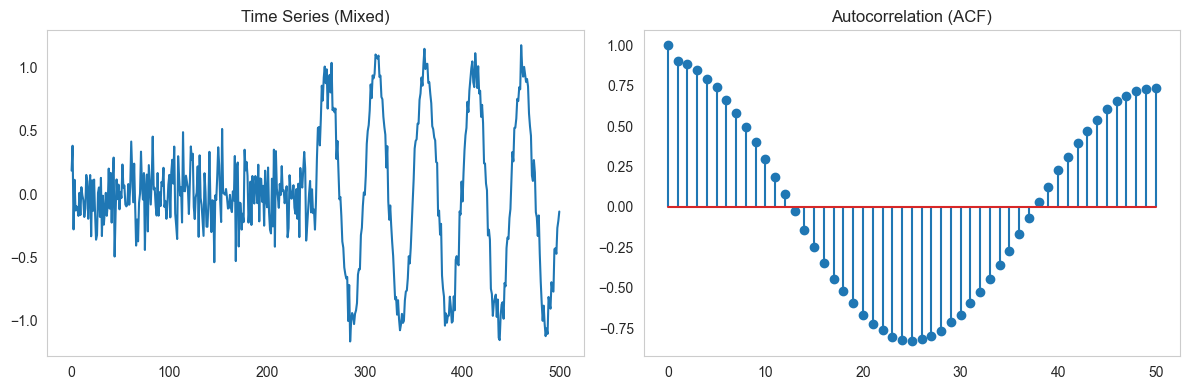

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf
from scipy.signal import periodogram

# Simulated time series: oscillating + non-oscillating
np.random.seed(42)
t = np.linspace(0, 10, 500)
oscillating = np.sin(2 * np.pi * 1 * t) + 0.1 * np.random.randn(500)
non_oscillating = np.random.normal(0, 0.2, 500)
signal = np.concatenate([non_oscillating[:250], oscillating[250:]])

# ACF analysis
acf_values = acf(signal, nlags=50)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(signal)
plt.title("Time Series (Mixed)")
plt.grid()

plt.subplot(1, 2, 2)
plt.stem(acf_values)
plt.title("Autocorrelation (ACF)")
plt.grid()
plt.tight_layout()
plt.show()


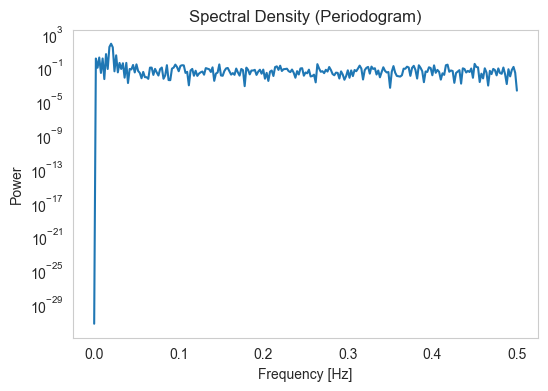

In [97]:
f, Pxx = periodogram(signal)



plt.figure(figsize=(6, 4))
plt.semilogy(f, Pxx)
plt.title("Spectral Density (Periodogram)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Power")
plt.grid()
plt.show()


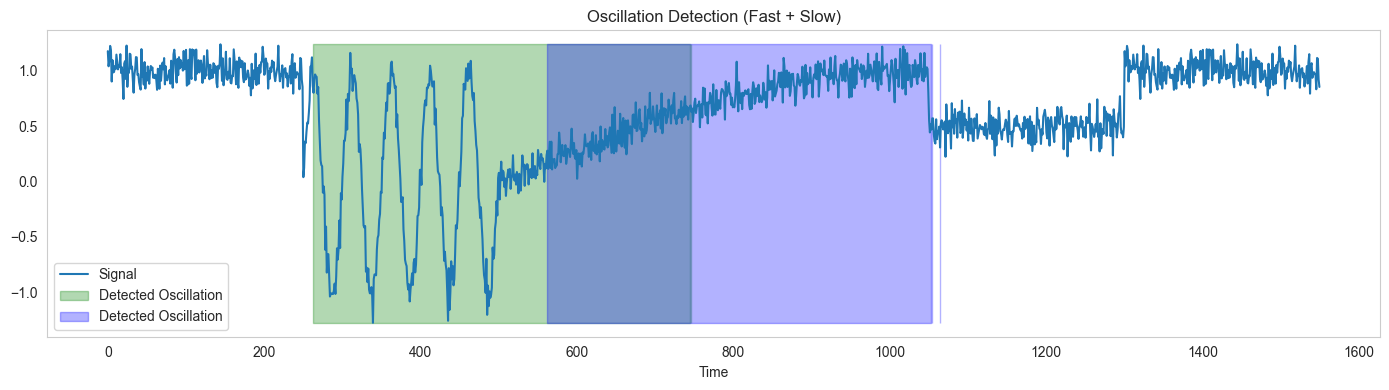

Flat regions (start, end indices): [(202, 992), (994, 994), (1004, 1004)]
Total oscillating indices: 793


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

def detect_oscillation(signal, window_size, acf_lags, threshold):
    flags = []
    for i in range(len(signal) - window_size + 1):
        window = signal[i:i+window_size]
        acf_vals = acf(window, nlags=acf_lags, fft=False)
        max_acf = np.max(np.abs(acf_vals[1:]))
        flags.append(max_acf > threshold)
    return [False] * (window_size - 1) + flags

def shift_flags_forward(flags, window_size, shifter = 10):
    shift = window_size // shifter
    return flags[shift:] + [False]*shift

def extract_regions(flags):
    regions = []
    start = None
    for i, val in enumerate(flags):
        if val and start is None:
            start = i
        elif not val and start is not None:
            regions.append((start, i - 1))
            start = None
    if start is not None:
        regions.append((start, len(flags) - 1))
    return regions


# Create the signal
np.random.seed(0)
flat_1 = np.random.normal(0, 0.1, 250) + 1
flat_5 = np.random.normal(0, 0.1, 250) + 0.5
osc1 = np.sin(np.linspace(0, 10 * np.pi, 250)) + np.random.normal(0, 0.1, 250)
osc2 = np.sin(np.linspace(0, 0.5 * np.pi, 550)) + np.random.normal(0, 0.1, 550)
signal = np.concatenate([flat_1, osc1, osc2, flat_5, flat_1])
time = np.arange(len(signal))


# Detection settings
short_win = 300   # For fast oscillation (osc1)
long_win = 600    # For slow oscillation (osc2)
acf_lags = 50
threshold = 0.9  # Lower threshold for weak oscillation


# Run both short and long window detection
osc_flags_short = detect_oscillation(signal, short_win, acf_lags, threshold)
osc_flags_short = shift_flags_forward(osc_flags_short, long_win , shifter = acf_lags // 3)
osc_flags_long = detect_oscillation(signal, long_win, acf_lags, threshold)
osc_flags_long = shift_flags_forward(osc_flags_long, long_win , shifter = acf_lags // 3)


# Combine: either short or long detects → oscillation
osc_flags_combined = [s or l for s, l in zip(osc_flags_short, osc_flags_long)]
osc_flags_combined = shift_flags_forward(osc_flags_combined, long_win)# , shifter = acf_lags // 10)

# Plot results
plt.figure(figsize=(14, 4))
plt.plot(time, signal, label="Signal")
plt.fill_between(time, np.min(signal), np.max(signal), where=osc_flags_short, color='green', alpha=0.3, label="Detected Oscillation")
plt.fill_between(time, np.min(signal), np.max(signal), where=osc_flags_long, color='blue', alpha=0.3, label="Detected Oscillation")
plt.title("Oscillation Detection (Fast + Slow)")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Extracting the regions of detections
flat_regions = extract_regions(osc_flags_combined)
print("Flat regions (start, end indices):", flat_regions)

total_oscillating_indices = sum(osc_flags_combined)
print(f"Total oscillating indices: {total_oscillating_indices}")

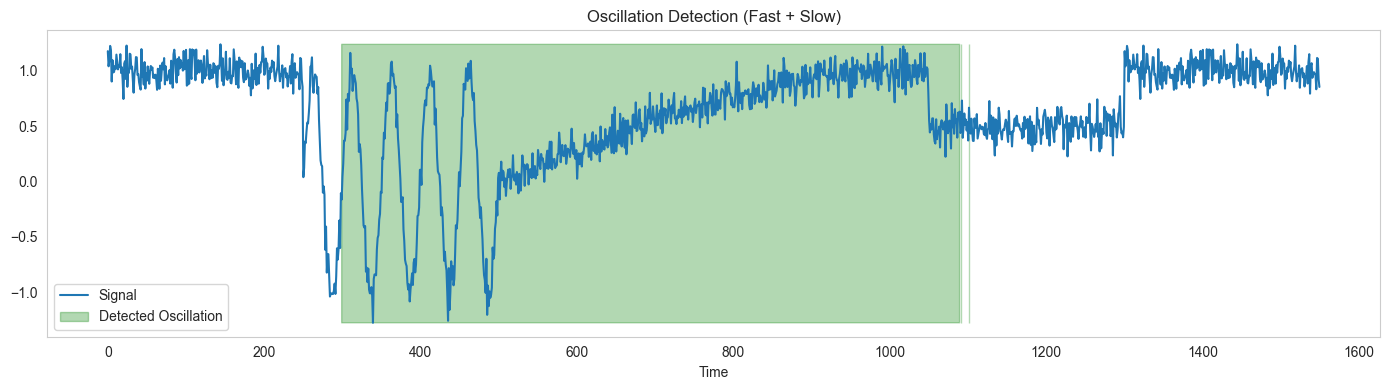

Flat regions (start, end indices): [(299, 1089), (1091, 1091), (1101, 1101)]
Total oscillating indices: 793


In [99]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

def detect_oscillation(signal, window_size, acf_lags, threshold):
    flags = []
    for i in range(len(signal) - window_size + 1):
        window = signal[i:i+window_size]
        acf_vals = acf(window, nlags=acf_lags, fft=False)
        max_acf = np.max(np.abs(acf_vals[1:]))
        flags.append(max_acf > threshold)
    return [False] * (window_size - 1) + flags

def detect_flat(signal, window_size, acf_lags, threshold):
    flags = []
    for i in range(len(signal) - window_size + 1):
        window = signal[i:i+window_size]
        acf_vals = acf(window, nlags=acf_lags, fft=False)
        max_acf = np.max(np.abs(acf_vals[1:]))
        is_flat = max_acf < threshold  # INVERTED condition
        flags.append(is_flat)
    return [False] * (window_size - 1) + flags

def shift_flags_forward(flags, window_size):
    shift = window_size // 10
    return flags[shift:] + [False]*shift

def extract_regions(flags):
    regions = []
    start = None
    for i, val in enumerate(flags):
        if val and start is None:
            start = i
        elif not val and start is not None:
            regions.append((start, i - 1))
            start = None
    if start is not None:
        regions.append((start, len(flags) - 1))
    return regions


# Create the signal
np.random.seed(0)
flat_1 = np.random.normal(0, 0.1, 250) + 1
flat_5 = np.random.normal(0, 0.1, 250) + 0.5
osc1 = np.sin(np.linspace(0, 10 * np.pi, 250)) + np.random.normal(0, 0.1, 250)
osc2 = np.sin(np.linspace(0, 0.5 * np.pi, 550)) + np.random.normal(0, 0.1, 550)
signal = np.concatenate([flat_1, osc1, osc2, flat_5, flat_1])
time = np.arange(len(signal))


# Detection settings
short_win = 300   # For fast oscillation (osc1)
long_win = 600    # For slow oscillation (osc2)
acf_lags = 100
threshold = 0.9  # Lower threshold for weak oscillation


# Run both short and long window detection
osc_flags_short = detect_oscillation(signal, short_win, acf_lags, threshold)
osc_flags_long = detect_oscillation(signal, long_win, acf_lags, threshold)

# Combine: either short or long detects → oscillation
osc_flags_combined = [s or l for s, l in zip(osc_flags_short, osc_flags_long)]


# Plot results
plt.figure(figsize=(14, 4))
plt.plot(time, signal, label="Signal")
plt.fill_between(time, np.min(signal), np.max(signal), where=osc_flags_combined, color='green', alpha=0.3, label="Detected Oscillation")
plt.title("Oscillation Detection (Fast + Slow)")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Extracting the regions of detections
flat_regions = extract_regions(osc_flags_combined)
print("Flat regions (start, end indices):", flat_regions)

total_oscillating_indices = sum(osc_flags_combined)
print(f"Total oscillating indices: {total_oscillating_indices}")

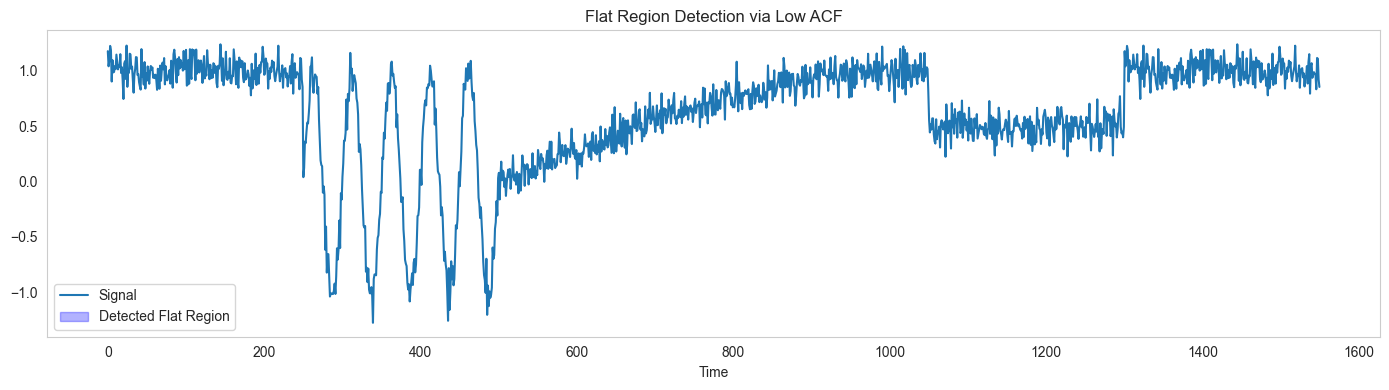

In [100]:
# Set parameters for slow waves
long_win = 200
acf_lags = 100
threshold = 0.1  # Adjust if needed


def detect_flat(signal, window_size, acf_lags, threshold):
    flags = []
    for i in range(len(signal) - window_size + 1):
        window = signal[i:i+window_size]
        acf_vals = acf(window, nlags=acf_lags, fft=False)
        max_acf = np.max(np.abs(acf_vals[1:]))
        is_flat = max_acf < threshold  # INVERTED condition
        flags.append(is_flat)
    return [False] * (window_size - 1) + flags

# Detect flat regions
flat_flags = detect_flat(signal, long_win, acf_lags, threshold)

# Plot
plt.figure(figsize=(14, 4))
plt.plot(time, signal, label="Signal")
plt.fill_between(time, np.min(signal), np.max(signal), where=flat_flags, color='blue', alpha=0.3, label="Detected Flat Region")
plt.title("Flat Region Detection via Low ACF")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [101]:
filtered_test_data_2024.columns

NameError: name 'filtered_test_data_2024' is not defined

In [ ]:
df = autocorrelation_check(filtered_test_data_2024, 'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', window_size=30, acf_lags=10, acf_threshold=0.9)
df

# Plot
plt.figure(figsize=(14, 4))
plt.plot(df['Time'], df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'], label="Signal")
plt.fill_between(df['Time'], np.min(df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)']), np.max(df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)']), where=df['ac_ws1000_lags100_thres0.1'], color='blue', alpha=0.3, label="Detected Flat Region")
plt.title("Flat Region Detection via Low ACF")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
train_data_base = train_data.copy()
test_data_base = test_data.copy()

display(train_data_base)
print(f'train TRUE values : {train_data_base[train_data_base['Generator_ON']].shape[0]}')
display(test_data_base)
print(f'test TRUE values : {test_data_base[test_data_base['Generator_ON']].shape[0]}')

In [ ]:
# Applying a bias for only the generator voltage

test_data_base_new = test_data_base.copy()
test_data_base_new['Time'] = pd.to_datetime(test_data_base_new['Time'], format="%m/%d/%y %H:%M")
test_data_base_new.sort_values(by='Time', inplace=True)
volt_col = 'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'

# Replace values under 170 with NaN, then forward-fill
test_data_base_new[volt_col] = test_data_base_new[volt_col].mask(test_data_base_new[volt_col] < 170, np.nan).ffill()

# Filtering data
start_date = '2024-08-22 00:00:00'
test_data_base_new = test_data_base_new[(test_data_base_new['Time'] >= start_date)]

# Making a new shifted values only for the Generator ON == True for test case of Autocorrelation
test_data_base_new['New_Volt_Lab'] = test_data_base_new.apply(
    lambda row: (row['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'] - 20)
    if (row['Generator_ON'] and row['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'] > 5)
    else row['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'],
    axis=1
)

mean_diff = test_data_base_new[ (test_data_base_new['Generator_ON']) ]['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'].mean() - test_data_base_new[ ~(test_data_base_new['Generator_ON']) ]['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'].mean()
print(f'mean_diff : {mean_diff}')

df = test_data_base_new
display(df[df['Generator_ON']])

is_valid, invalid_data = check_time_intervals(df)

# If there are invalid rows, display them
if not is_valid:
    print("Invalid rows:")
    display(invalid_data)


# Ploting the data
# Plot
plt.figure(figsize=(14, 4))
plt.plot(df['Time'], df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'], label="Signal")
plt.fill_between(df['Time'], np.min(df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)']), np.max(df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)']), where=df['Generator_ON'], color='blue', alpha=0.3, label="Detected Flat Region")
plt.title("Actual Cleanned Lab Voltage")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [ ]:
# Ploting the New Volt Lab column

plt.figure(figsize=(14, 4))
plt.plot(df['Time'], df['New_Volt_Lab'], label="Signal")
plt.fill_between(df['Time'], np.min(df['New_Volt_Lab']), np.max(df['New_Volt_Lab']), where=df['Generator_ON'], color='blue', alpha=0.3, label="Generator ON")
plt.title("New Volt Lab (Shifted and Cleaned)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
clean_signal = df['New_Volt_Lab'].replace(0, np.nan).ffill()

# Re-run ACF with cleaned signal
plot_acf(clean_signal.dropna(), lags=1400)
plt.title("ACF after Removing Zero Entries")
plt.show()

In [102]:
clean_signal = df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'].replace(0, np.nan).ffill()

# Re-run ACF with cleaned signal
plot_acf(clean_signal.dropna(), lags=1400)
plt.title("ACF after Removing Zero Entries & Differencing")
plt.show()

NameError: name 'df' is not defined

In [103]:
clean_signal = df['New_Volt_Lab'].replace(0, np.nan).ffill()

# Re-run ACF with cleaned signal
plot_acf(clean_signal.diff().dropna(), lags=20)
plt.title("ACF after Removing Zero Entries & Differencing")
plt.show()

# Re-run ACF with cleaned signal with higher lags
plot_acf(clean_signal.diff().dropna(), lags=1400)
plt.title("ACF for Daily Seasonality Check")
plt.show()

NameError: name 'df' is not defined

In [104]:
clean_signal = df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'].replace(0, np.nan).ffill()

# Re-run ACF with cleaned signal
plot_acf(clean_signal.diff().dropna(), lags=100)
plt.title("ACF after Removing Zero Entries & Differencing")
plt.show()


plot_acf(clean_signal.diff().dropna(), lags=1440)
plt.title("ACF for Daily Seasonality Check")
plt.show()

NameError: name 'df' is not defined

### 1. Hidden Ruptures Model

In [105]:
import ruptures as rpt
import matplotlib.pyplot as plt

# Smoothed signal
df['smoothed_voltage'] = df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'].rolling(window=10).mean().fillna(method='bfill')
signal_array = df['smoothed_voltage'].to_numpy()

# Initialize and fit model
model = "l2"
algo = rpt.Pelt(model=model).fit(signal_array)

# Tune penalty to reduce noise — try 50, 100, etc.
change_points = algo.predict(pen=5000)

# Plot change points
plt.figure(figsize=(140, 4))
rpt.display(signal_array, change_points)
plt.title("Change Point Detection on Smoothed New_Volt_Lab")
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

### 2. Hidden Markov Model

In [106]:
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt
import numpy as np

# Choose number of states to test (3 or 4)
n_states = 4  # or 3

# Use adjusted signal if available, e.g. 'New_Volt_Lab'
X = df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'].to_numpy().reshape(-1, 1)

# Fit HMM
hmm = GaussianHMM(n_components=n_states, covariance_type="full", n_iter=1000, random_state=42)
hmm.fit(X)
df['HMM_State'] = hmm.predict(X)

# Show mean voltage per state for interpretation
state_means = df.groupby('HMM_State')['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'].mean().sort_values()
print("Mean voltage per state:")
print(state_means)

# Plot each state in a different color
plt.figure(figsize=(14, 4))
plt.plot(df['Time'], df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'], label='Voltage', color='black')

colors = ['blue', 'green', 'red', 'purple']
for idx, state in enumerate(state_means.index):
    plt.fill_between(
        df['Time'],
        df['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)'],
        where=(df['HMM_State'] == state),
        color=colors[idx % len(colors)],
        alpha=0.2,
        label=f'HMM State {state} (mean={state_means[state]:.1f})'
    )

plt.title(f"Voltage with HMM-Inferred States (n_components={n_states})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf


# Create the signal
start_date = '2024-10-01 00:00:00'
finished_date = '2024-10-20 23:59:59'
filtered_test_data_2024 = test_data_2024[(test_data_2024['Time'] >= start_date) & (test_data_2024['Time'] <= finished_date)]
signal = filtered_test_data_2024['Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)']
time = np.arange(len(signal))


# Detection settings
short_win = 500 # For fast oscillation (osc1)
long_win = 100   # For slow oscillation (osc2)
acf_lags = 100
threshold = 0.2  # Lower threshold for weak oscillation


# Run both short and long window detection
osc_flags_short = detect_flat(signal, short_win, acf_lags, threshold)
osc_flags_long = detect_flat(signal, long_win, acf_lags, threshold)

# Combine: either short or long detects → oscillation
osc_flags_combined = [s or l for s, l in zip(osc_flags_short, osc_flags_long)]


# Plot results
plt.figure(figsize=(14, 4))
plt.plot(time, signal, label="Signal")
plt.fill_between(time, np.min(signal), np.max(signal), where=osc_flags_short, color='green', alpha=0.3, label="Detected Oscillation")
plt.fill_between(time, np.min(signal), np.max(signal), where=osc_flags_long, color='blue', alpha=0.3, label="Detected Oscillation")
plt.title("Oscillation Detection (Fast + Slow)")
plt.xlabel("Time")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Extracting the regions of detections
flat_regions = extract_regions(osc_flags_combined)
print("Flat regions (start, end indices):", flat_regions)

total_oscillating_indices = sum(osc_flags_combined)
print(f"Total oscillating indices: {total_oscillating_indices}")

In [ ]:
temp = signal.to_numpy()
temp
signal.values

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

temps = signal.values

acf_plot = plot_acf(temps, lags = 100)
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf

differenced = signal.diff().dropna()

plot_acf(differenced, lags=100)
plt.title("ACF of Differenced Signal")
plt.show()

In [ ]:
print("Number of zero entries:", (signal == 0).sum())


In [ ]:
clean_signal = signal.replace(0, np.nan).ffill()

# Re-run ACF with cleaned signal
plot_acf(clean_signal.diff().dropna(), lags=100)
plt.title("ACF after Removing Zero Entries & Differencing")
plt.show()

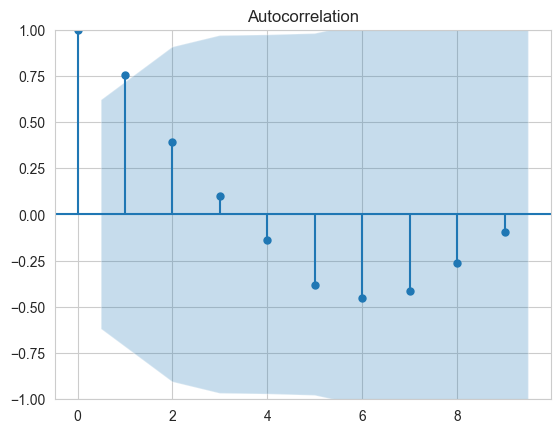

In [107]:
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Sample data: Daily temperatures
temps = [22.1, 21.9, 22.5, 23.0, 22.8, 23.5, 23.9, 24.2, 24.0, 23.7]
series = pd.Series(temps)

# Plot ACF
plot_acf(series, lags=9)
plt.show()


In [108]:
temps

[22.1, 21.9, 22.5, 23.0, 22.8, 23.5, 23.9, 24.2, 24.0, 23.7]

In [109]:
# Plot predictions based on certain timing choosen

start_date = '2024-10-11 00:00:00'
finished_date = '2024-10-20 23:59:59'
filtered_test_data_2024 = test_data_2024[(test_data_2024['Time'] >= start_date) & (test_data_2024['Time'] <= finished_date)]

autocorrelation_check(filtered_test_data_2024, 'Voltage 3E2F4FD3 (Ch Cbca Bethesda Ndosho - laboratoire)', 200, acf_lags, acf_threshold)


# Plot based on the filtered time:
plot_predictions(
    filtered_test_data_2024,
    model_name=f"Mean - Random Forest (Train Set) for New Data between {start_date} and {finished_date}: ",
    include_voltage=True,
    include_frequency=True
)

NameError: name 'test_data_2024' is not defined